In [2]:
# ==============================================================================
# Reproducibility Note: To comply with strict reproducibility standards, a fixed
# random seed (random_state=42) is globally enforced across all operations.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Enforce global seed for absolute determinism
np.random.seed(42)

# ==============================================================================
# Step 1: Data Loading & Setup
# ==============================================================================
data_path = 'My dataset with class and without missing values.csv'
print(f"Loading harmonized dataset from '{data_path}'...")
df = pd.read_csv(data_path)

# Encode the target severity labels
le = LabelEncoder()
y = le.fit_transform(df['mag class'])
class_names = le.classes_.tolist()

# Define the Severe Classes for specific Recall calculation (Strong & Major)
severe_indices = [class_names.index(c) for c in class_names if c in ['Strong', 'Major']]

Loading harmonized dataset from 'My dataset with class and without missing values.csv'...


In [3]:
# ==============================================================================
# Step 2: Define Feature Representations
# ==============================================================================
# 2a. Full Feature Set
full_features = [
    'Day', 'Month', 'Year', 'Hour', 'Min', 'Sec',
    'latitude', 'longitude', 'depth', 'magType',
    'gap', 'rms', 'horizontalError', 'depthError','magError','mag'
]
X_full = df[full_features]
X_full = pd.get_dummies(X_full, columns=['magType'], drop_first=True)

# 2b. SHFSF Feature Set (6 Features)
shfsf_features = ['mag', 'magType', 'Year', 'gap', 'magError', 'depth']
X_shfsf = df[shfsf_features]
X_shfsf = pd.get_dummies(X_shfsf, columns=['magType'], drop_first=True)

# Train-Test Splitting function to ensure exact 70:30 stratified split consistency
def prepare_data(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.30, random_state=42, stratify=y_data
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [4]:
# ==============================================================================
# Step 3: Comparative Benchmarking
# ==============================================================================
print("\n" + "="*60)
print("TABLE 2: Comparative Benchmarking of Feature Representations")
print("="*60)

# Initialize the proxy classifier (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

def evaluate_strategy(name, X_tr, X_te, y_tr, y_te, model):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)

    acc = accuracy_score(y_te, y_pred) * 100
    f1 = f1_score(y_te, y_pred, average='weighted') * 100
    prec = precision_score(y_te, y_pred, average='weighted') * 100

    y_te_bin = label_binarize(y_te, classes=np.arange(len(class_names)))
    roc_auc = roc_auc_score(y_te_bin, y_prob, average='macro', multi_class="ovr")

    recalls = recall_score(y_te, y_pred, average=None)
    severe_recall = np.mean([recalls[idx] for idx in severe_indices]) * 100

    print(f"Strategy: {name}")
    print(f"Accuracy: {acc:.2f}% | Precision: {prec:.2f}% | Severe Recall: {severe_recall:.2f}% | F1: {f1:.2f}% | ROC-AUC: {roc_auc:.3f}\n")

# Evaluate Strategy 1: Full Feature Set
X_train_f, X_test_f, y_train_f, y_test_f, _ = prepare_data(X_full, y)
evaluate_strategy("Full Feature Set", X_train_f, X_test_f, y_train_f, y_test_f, knn_model)

# Evaluate Strategy 2: PCA (9 Components)
pca = PCA(n_components=9, random_state=42)
X_train_pca = pca.fit_transform(X_train_f)
X_test_pca = pca.transform(X_test_f)
evaluate_strategy("PCA (9 Components)", X_train_pca, X_test_pca, y_train_f, y_test_f, knn_model)

# Evaluate Strategy 3: SHFSF (Proposed)
X_train_s, X_test_s, y_train_s, y_test_s, scaler_shfsf = prepare_data(X_shfsf, y)
evaluate_strategy("SHFSF (6 Features)", X_train_s, X_test_s, y_train_s, y_test_s, knn_model)


TABLE 2: Comparative Benchmarking of Feature Representations
Strategy: Full Feature Set
Accuracy: 93.59% | Precision: 93.12% | Severe Recall: 33.21% | F1: 93.15% | ROC-AUC: 0.933

Strategy: PCA (9 Components)
Accuracy: 94.04% | Precision: 93.67% | Severe Recall: 21.91% | F1: 93.63% | ROC-AUC: 0.918

Strategy: SHFSF (6 Features)
Accuracy: 98.90% | Precision: 98.89% | Severe Recall: 70.41% | F1: 98.88% | ROC-AUC: 0.981



In [5]:
# ==============================================================================
# Step 4: Model Selection & Performance on SHFSF
# ==============================================================================
print("\n" + "="*60)
print("TABLE 3: SHFSF Performance across Classifiers (Test Set Metrics)")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
    'SVM': SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'AdaBoost': AdaBoostClassifier(n_estimators=150, learning_rate=0.8, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.05, random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_s, y_train_s)
    trained_models[name] = model

    y_train_pred = model.predict(X_train_s)
    y_test_pred = model.predict(X_test_s)

    train_acc = accuracy_score(y_train_s, y_train_pred) * 100
    test_acc = accuracy_score(y_test_s, y_test_pred) * 100
    prec = precision_score(y_test_s, y_test_pred, average='weighted') * 100
    rec = recall_score(y_test_s, y_test_pred, average='weighted') * 100
    f1 = f1_score(y_test_s, y_test_pred, average='weighted') * 100

    print(f"{name:<20} | Train Acc: {train_acc:>6.2f}% | Test Acc: {test_acc:>6.2f}% | Prec: {prec:>6.2f}% | Rec: {rec:>6.2f}% | F1: {f1:>6.2f}%")


TABLE 3: SHFSF Performance across Classifiers (Test Set Metrics)
Logistic Regression  | Train Acc:  99.88% | Test Acc:  99.85% | Prec:  99.85% | Rec:  99.85% | F1:  99.84%
Decision Tree        | Train Acc: 100.00% | Test Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%
Random Forest        | Train Acc: 100.00% | Test Acc:  99.93% | Prec:  99.93% | Rec:  99.93% | F1:  99.93%
SVM                  | Train Acc:  99.46% | Test Acc:  99.33% | Prec:  99.34% | Rec:  99.33% | F1:  99.31%
KNN                  | Train Acc:  99.28% | Test Acc:  98.90% | Prec:  98.89% | Rec:  98.90% | F1:  98.88%
AdaBoost             | Train Acc:  99.85% | Test Acc:  99.86% | Prec:  99.74% | Rec:  99.86% | F1:  99.80%
XGBoost              | Train Acc: 100.00% | Test Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%



FIGURE 4: Generating Multi-Panel Confusion Matrices
Saved high-resolution image: 'Multi_Panel_Confusion_Matrices_SHFSF.tiff'


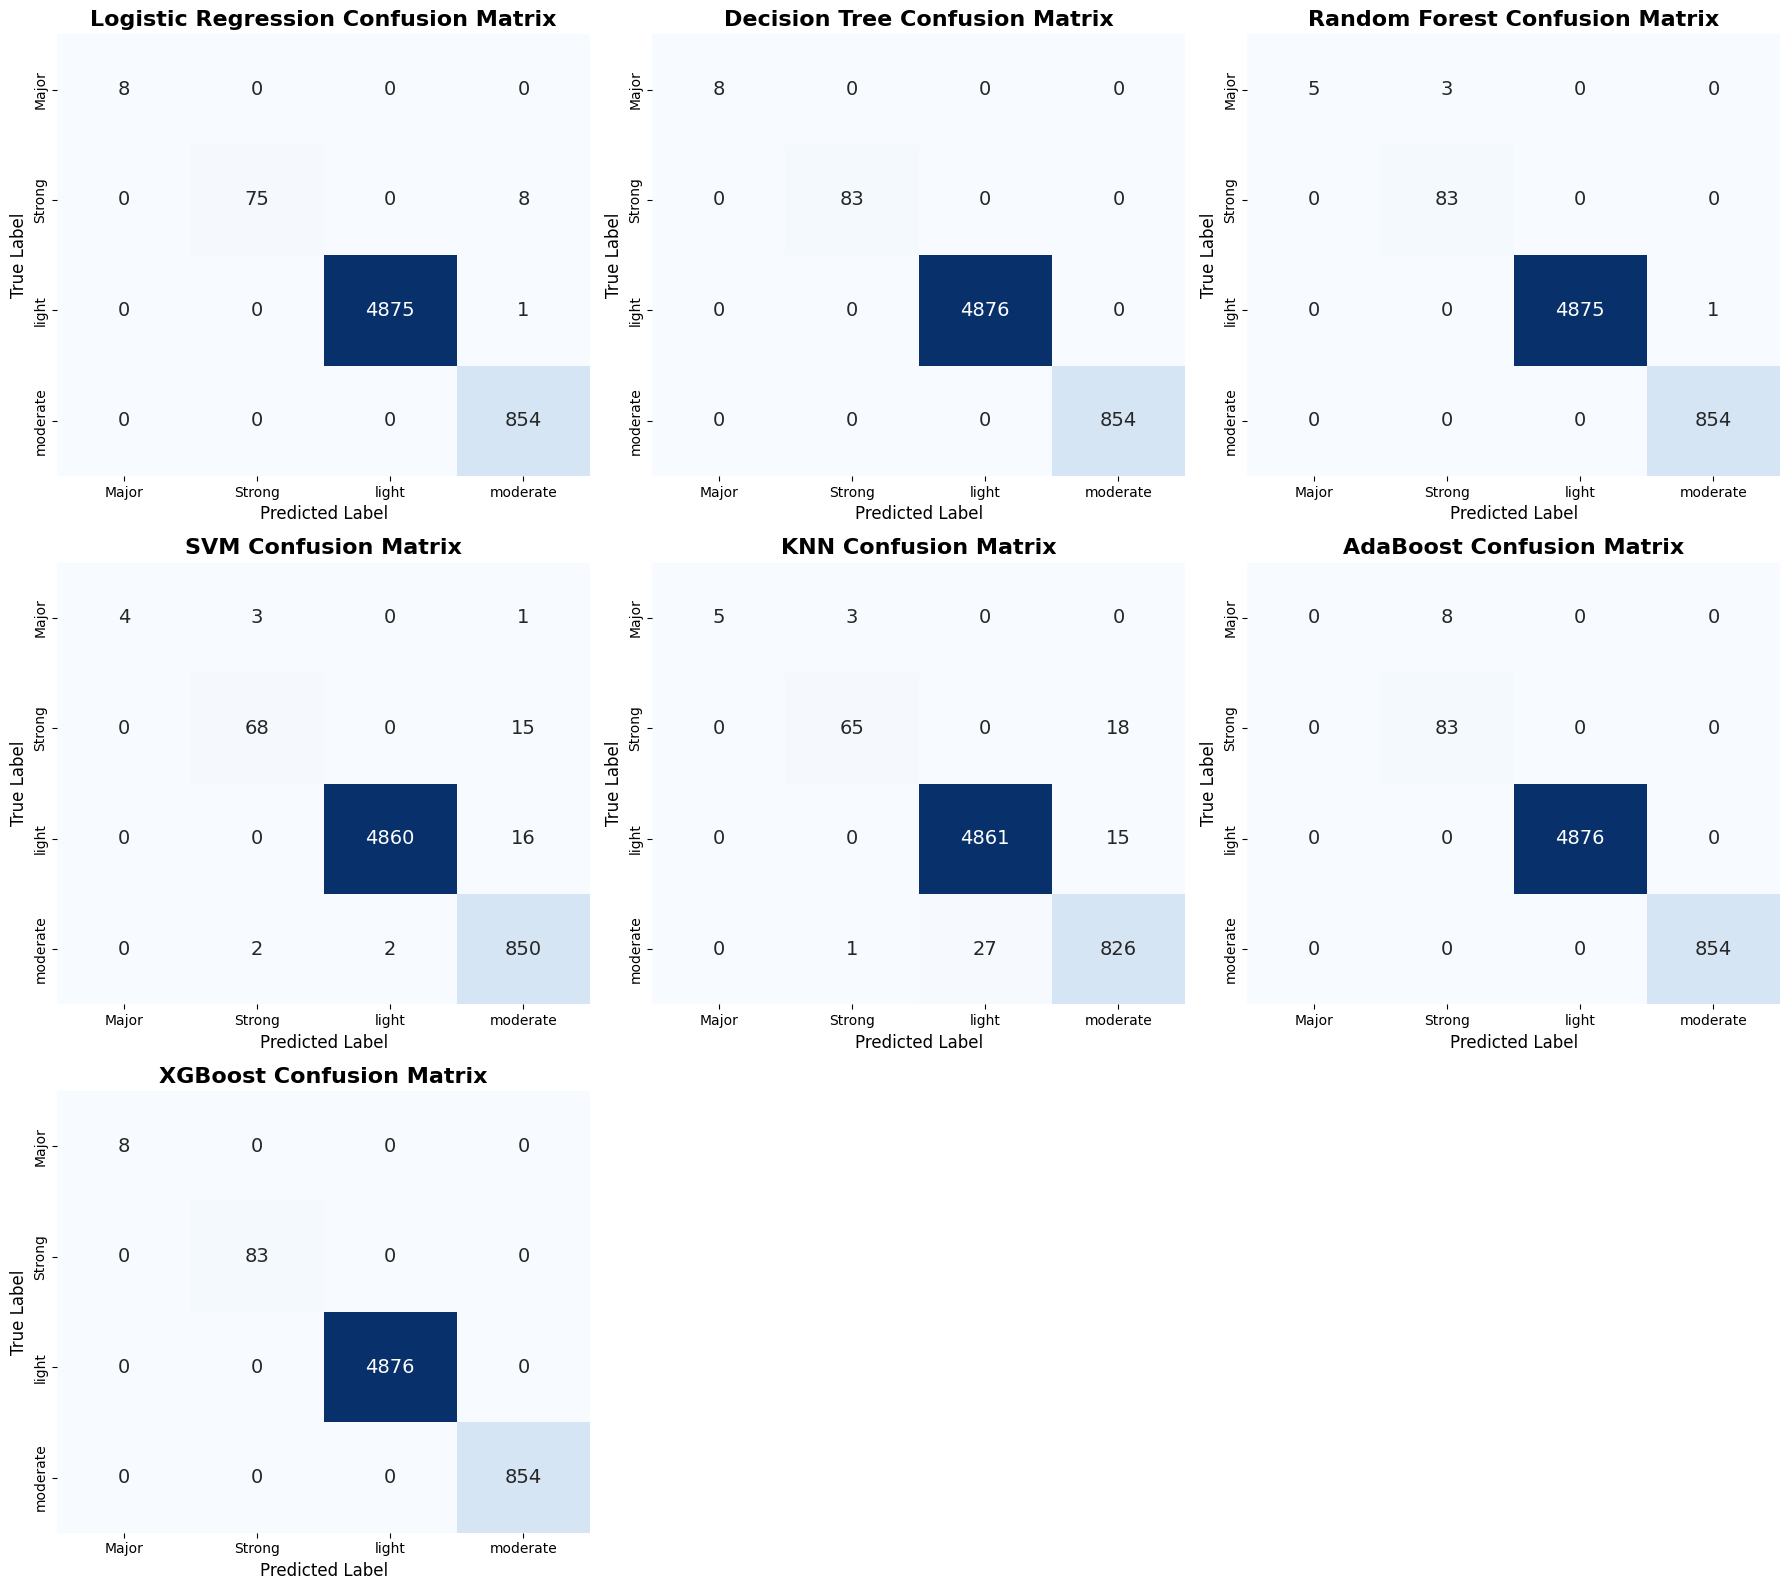

In [15]:
# ==============================================================================
# Step 5: Visualizing Confusion Matrices
# ==============================================================================
print("\n" + "="*60)
print("FIGURE 4: Generating Multi-Panel Confusion Matrices")
print("="*60)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_test_pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test_s, y_test_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False,
                annot_kws={"size": 14})

    axes[i].set_title(f'{name} Confusion Matrix', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

# Hide unused subplots (7 models, 9 subplots total)
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.savefig('Multi_Panel_Confusion_Matrices_SHFSF.tiff', dpi=300, bbox_inches='tight')
print("Saved high-resolution image: 'Multi_Panel_Confusion_Matrices_SHFSF.tiff'")
plt.show()

In [16]:
# ==============================================================================
# Generating Individual Confusion Matrices (PNG format)
# ==============================================================================
print("\n" + "="*60)
print("Generating Individual Confusion Matrices (PNG format)")
print("="*60)

for name, model in trained_models.items():
    y_test_pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test_s, y_test_pred)

    fig_single, ax_single = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_single,
                xticklabels=class_names, yticklabels=class_names, cbar=False,
                annot_kws={"size": 24})

    ax_single.set_title(f'{name} Confusion Matrix', fontsize=20, fontweight='bold')
    ax_single.set_xlabel('Predicted Label', fontsize=20)
    ax_single.set_ylabel('True Label', fontsize=20)
    ax_single.set_xticklabels(class_names, fontsize=14)
    ax_single.set_yticklabels(class_names, fontsize=14)

    plt.tight_layout()
    # Safely replace spaces with underscores for filenames
    filename_png = f"Confusion_Matrix_{name.replace(' ', '_')}.png"
    fig_single.savefig(filename_png, dpi=300, bbox_inches='tight')
    print(f"Saved: '{filename_png}'")
    plt.close(fig_single)

print("\nIndividual confusion matrices have been successfully generated and saved.")


Generating Individual Confusion Matrices (PNG format)
Saved: 'Confusion_Matrix_Logistic_Regression.png'
Saved: 'Confusion_Matrix_Decision_Tree.png'
Saved: 'Confusion_Matrix_Random_Forest.png'
Saved: 'Confusion_Matrix_SVM.png'
Saved: 'Confusion_Matrix_KNN.png'
Saved: 'Confusion_Matrix_AdaBoost.png'
Saved: 'Confusion_Matrix_XGBoost.png'

Individual confusion matrices have been successfully generated and saved.
